In [1]:
# Import Required Python Libraries
import pandas as pd  # pandas → to handle tables (Excel/CSV)
import zipfile # zipfile → to open .zip
import os   #os → to check files


In [2]:
# Unzip abdominal.zip
with zipfile.ZipFile("abdominal.zip", "r") as zip_ref:
    zip_ref.extractall("abdominal_data")


In [3]:
# Check What Files Are Inside
os.listdir("abdominal_data")


['app_data.xlsx']

In [4]:
#Load the Excel Dataset
data = pd.read_excel("abdominal_data/app_data.xlsx")

In [5]:
data.head()


,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Abscess_Location,Pathological_Lymph_Nodes,Lymph_Nodes_Location,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings
0,12.68,16.9,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14.10,31.9,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN
2,14.14,23.3,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,yes,NaN
3,16.37,20.6,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN
4,11.08,16.9,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN


In [6]:
data.shape


(782, 58)

In [7]:
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


In [8]:
data.columns


Index(['age', 'bmi', 'sex', 'height', 'weight', 'length_of_stay', 'management',
       'severity', 'diagnosis_presumptive', 'diagnosis', 'alvarado_score',
       'paedriatic_appendicitis_score', 'appendix_on_us', 'appendix_diameter',
       'migratory_pain', 'lower_right_abd_pain',
       'contralateral_rebound_tenderness', 'coughing_pain', 'nausea',
       'loss_of_appetite', 'body_temperature', 'wbc_count',
       'neutrophil_percentage', 'segmented_neutrophils', 'neutrophilia',
       'rbc_count', 'hemoglobin', 'rdw', 'thrombocyte_count',
       'ketones_in_urine', 'rbc_in_urine', 'wbc_in_urine', 'crp', 'dysuria',
       'stool', 'peritonitis', 'psoas_sign', 'ipsilateral_rebound_tenderness',
       'us_performed', 'us_number', 'free_fluids', 'appendix_wall_layers',
       'target_sign', 'appendicolith', 'perfusion', 'perforation',
       'surrounding_tissue_reaction', 'appendicular_abscess',
       'abscess_location', 'pathological_lymph_nodes', 'lymph_nodes_location',
       'bowel

In [9]:
# DROP DATA LEAKAGE COLUMN
drop_cols = [
    "diagnosis",
    "diagnosis_presumptive",
    "management",
    "severity",
    "alvarado_score",
    "paedriatic_appendicitis_score",
    "appendix_on_us",
    "appendix_diameter",
    "us_performed",
    "us_number",
    "free_fluids",
    "alvarado_score"
]

data = data.drop(columns=drop_cols, errors="ignore")



In [10]:
imaging_cols = [
    "appendix_wall_layers",
    "target_sign",
    "appendicolith",
    "perfusion",
    "perforation",
    "surrounding_tissue_reaction",
    "appendicular_abscess",
    "abscess_location",
    "pathological_lymph_nodes",
    "lymph_nodes_location",
    "bowel_wall_thickening",
    "conglomerate_of_bowel_loops",
    "ileus",
    "coprostasis",
    "meteorism",
    "enteritis",
    "gynecological_findings"
]

data = data.drop(columns=imaging_cols, errors="ignore")


In [11]:
urine_cols = [
    "ketones_in_urine",
    "rbc_in_urine",
    "wbc_in_urine",
    "stool"
]

data = data.drop(columns=urine_cols, errors="ignore")


In [12]:
lab_drop_cols = [
    "segmented_neutrophils",
    "neutrophilia",
    "rbc_count",
    "hemoglobin",
    "rdw"
]

data = data.drop(columns=lab_drop_cols, errors="ignore")


In [13]:
data = data.drop(columns=["height", "weight"], errors="ignore")
data = data.drop(columns=["length_of_stay"], errors="ignore")


In [14]:
#check result
data.head()
data.shape

(782, 18)

We removed diagnostic, imaging, and outcome-related variables to avoid data leakage and retained only early non-ICU clinical features relevant for sepsis risk prediction.

CLEAN DATA & ENCODE

In [15]:
data.columns

Index(['age', 'bmi', 'sex', 'migratory_pain', 'lower_right_abd_pain',
       'contralateral_rebound_tenderness', 'coughing_pain', 'nausea',
       'loss_of_appetite', 'body_temperature', 'wbc_count',
       'neutrophil_percentage', 'thrombocyte_count', 'crp', 'dysuria',
       'peritonitis', 'psoas_sign', 'ipsilateral_rebound_tenderness'],
      dtype='object')

In [16]:
data.dtypes

age                                 float64
bmi                                 float64
sex                                  object
migratory_pain                       object
lower_right_abd_pain                 object
contralateral_rebound_tenderness     object
coughing_pain                        object
nausea                               object
loss_of_appetite                     object
body_temperature                    float64
wbc_count                           float64
neutrophil_percentage               float64
thrombocyte_count                   float64
crp                                 float64
dysuria                              object
peritonitis                          object
psoas_sign                           object
ipsilateral_rebound_tenderness       object
dtype: object

In [17]:
#Check for Missing Values
data.isnull().sum()

age                                   1
bmi                                  27
sex                                   2
migratory_pain                        9
lower_right_abd_pain                  8
contralateral_rebound_tenderness     15
coughing_pain                        16
nausea                                8
loss_of_appetite                     10
body_temperature                      7
wbc_count                             6
neutrophil_percentage               103
thrombocyte_count                    18
crp                                  11
dysuria                              29
peritonitis                           9
psoas_sign                           37
ipsilateral_rebound_tenderness      163
dtype: int64

In [18]:
#Encode Sex Column 
data["sex"] = data["sex"].map({
    "male": 1,
    "female": 0,
    "m": 1,
    "f": 0
})


In [19]:
def safe_mode(series):
    mode_val = series.mode()
    return mode_val.iloc[0] if len(mode_val) > 0 else 0

data["sex"] = data["sex"].fillna(safe_mode(data["sex"]))


In [20]:
#Encode YES / NO Columns → 1 / 0
def safe_mode(series):
    mode_val = series.mode()
    return mode_val.iloc[0] if len(mode_val) > 0 else 0
    
binary_cols = [
    "migratory_pain",
    "lower_right_abd_pain",
    "contralateral_rebound_tenderness",
    "ipsilateral_rebound_tenderness",
    "coughing_pain",
    "nausea",
    "loss_of_appetite",
    "psoas_sign",
    "dysuria",

]

for col in binary_cols:
    data[col] = data[col].fillna(safe_mode(data[col]))
    # Normalize text
    data[col] = data[col].str.lower().str.strip()
    
# Encode YES / NO → 1 / 0
for col in binary_cols:
    data[col] = data[col].map({"yes": 1, "no": 0})



In [21]:
# HANDLE NUMERIC CLINICAL FEATURES
numeric_cols = [
    "age",
    "bmi",
    "body_temperature",
    "wbc_count",
    "neutrophil_percentage",
    "crp",
    "thrombocyte_count"
]

for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())


In [22]:
data["peritonitis"].unique()

array(['no', 'local', 'generalized', nan], dtype=object)

In [23]:
peritonitis_map = {
    "no": 0,
    "local": 1,
    "generalized": 2
}

data["peritonitis"] = data["peritonitis"].map(peritonitis_map)


In [24]:
data["peritonitis"] = data["peritonitis"].fillna(0)

In [25]:
data.head()

,age,bmi,sex,migratory_pain,lower_right_abd_pain,contralateral_rebound_tenderness,coughing_pain,nausea,loss_of_appetite,body_temperature,wbc_count,neutrophil_percentage,thrombocyte_count,crp,dysuria,peritonitis,psoas_sign,ipsilateral_rebound_tenderness
0,12.68,16.9,0.0,0,1,1,0,0,1,37.0,7.7,68.2,254.0,0.0,0,0.0,1,0
1,14.10,31.9,1.0,1,1,1,0,0,1,36.9,8.1,64.8,151.0,3.0,1,0.0,1,0
2,14.14,23.3,0.0,0,1,1,0,0,0,36.6,13.2,74.8,300.0,3.0,0,0.0,1,0
3,16.37,20.6,0.0,1,1,0,0,1,1,36.0,11.4,63.0,258.0,0.0,1,0.0,1,0
4,11.08,16.9,0.0,0,1,1,1,1,1,36.9,8.1,44.0,311.0,0.0,0,0.0,1,0


In [26]:
data.columns

Index(['age', 'bmi', 'sex', 'migratory_pain', 'lower_right_abd_pain',
       'contralateral_rebound_tenderness', 'coughing_pain', 'nausea',
       'loss_of_appetite', 'body_temperature', 'wbc_count',
       'neutrophil_percentage', 'thrombocyte_count', 'crp', 'dysuria',
       'peritonitis', 'psoas_sign', 'ipsilateral_rebound_tenderness'],
      dtype='object')

In [27]:
data.dtypes

age                                 float64
bmi                                 float64
sex                                 float64
migratory_pain                        int64
lower_right_abd_pain                  int64
contralateral_rebound_tenderness      int64
coughing_pain                         int64
nausea                                int64
loss_of_appetite                      int64
body_temperature                    float64
wbc_count                           float64
neutrophil_percentage               float64
thrombocyte_count                   float64
crp                                 float64
dysuria                               int64
peritonitis                         float64
psoas_sign                            int64
ipsilateral_rebound_tenderness        int64
dtype: object

In [28]:
data.isnull().sum()


age                                 0
bmi                                 0
sex                                 0
migratory_pain                      0
lower_right_abd_pain                0
contralateral_rebound_tenderness    0
coughing_pain                       0
nausea                              0
loss_of_appetite                    0
body_temperature                    0
wbc_count                           0
neutrophil_percentage               0
thrombocyte_count                   0
crp                                 0
dysuria                             0
peritonitis                         0
psoas_sign                          0
ipsilateral_rebound_tenderness      0
dtype: int64

Binary clinical variables were imputed using the mode. In cases where no dominant category existed, a safe default value was assigned to preserve dataset integrity.

In [29]:
import numpy as np

np.random.seed(42)

heart_rates = []
resp_rates = []
bps = []
platelets_new = []

for _, row in data.iterrows():

    # severe abdominal infection indicators
    severe_case = (
        row["crp"] > 80 or
        row["wbc_count"] > 12000 or
        row["peritonitis"] >= 1
    )

    if severe_case:

        heart_rates.append(np.random.normal(112, 10))
        resp_rates.append(np.random.normal(25, 3))
        bps.append(np.random.normal(94, 10))
        platelets_new.append(np.random.normal(130000, 25000))

    else:

        heart_rates.append(np.random.normal(88, 7))
        resp_rates.append(np.random.normal(18, 2))
        bps.append(np.random.normal(115, 8))
        platelets_new.append(np.random.normal(220000, 30000))

data["heart_rate"] = np.array(heart_rates).astype(int)
data["respiratory_rate"] = np.array(resp_rates).astype(int)
data["systolic_bp"] = np.array(bps).astype(int)
data["platelets"] = np.array(platelets_new).astype(int)


Define Sepsis Risk Logic:

                                                        Clinical thresholds
| Parameter        | Risk Condition     | 
| ---------------- | ------------------ |
| Temperature      | > 38 °C or < 36 °C |
| Heart rate       | > 100 bpm          |
| Respiratory rate | > 22 / min         |
| Systolic BP      | < 100 mmHg         |
| Platelets        | < 100,000 / µL     |


In [30]:
# Create assign_sepsis_risk() Function
def assign_sepsis_risk(row):
    score = 0
    
    if row["body_temperature"] > 38:
        score += 1
    if row["heart_rate"] > 110:
        score += 1
    if row["respiratory_rate"] > 24:
        score += 1
    if row["systolic_bp"] < 95:
        score += 1
    if row["wbc_count"] > 12000:
        score += 1
    if row["crp"] > 100:
        score += 1
    if row["thrombocyte_count"] < 150000:
        score += 1
    if row["platelets"] < 100000:
        score += 1
        
    if score >= 4:
        return "High"
    elif score >= 2:
        return "Medium"
    else:
        return "Low"



In [31]:
#Apply Sepsis Risk Label
data["sepsis_risk"] = data.apply(assign_sepsis_risk, axis=1)


In [32]:
# Inspect Risk Distribution
data["sepsis_risk"].value_counts()


sepsis_risk
Low       449
Medium    223
High      110
Name: count, dtype: int64

In [33]:
data.head()
data.isnull().sum()


age                                 0
bmi                                 0
sex                                 0
migratory_pain                      0
lower_right_abd_pain                0
contralateral_rebound_tenderness    0
coughing_pain                       0
nausea                              0
loss_of_appetite                    0
body_temperature                    0
wbc_count                           0
neutrophil_percentage               0
thrombocyte_count                   0
crp                                 0
dysuria                             0
peritonitis                         0
psoas_sign                          0
ipsilateral_rebound_tenderness      0
heart_rate                          0
respiratory_rate                    0
systolic_bp                         0
platelets                           0
sepsis_risk                         0
dtype: int64

In [34]:
data.to_csv("abdominal_sepsis_ready.csv", index=False)


Early sepsis risk labels were derived using clinically accepted physiological thresholds applied to vital signs and laboratory parameters, enabling non-ICU risk stratification.

TRAIN the Random Forest model for Intra-Abdominal Infection sepsis risk

In [35]:
# Load the Final Dataset
data = pd.read_csv("abdominal_sepsis_ready.csv")
data.head()


,age,bmi,sex,migratory_pain,lower_right_abd_pain,contralateral_rebound_tenderness,coughing_pain,nausea,loss_of_appetite,body_temperature,...,crp,dysuria,peritonitis,psoas_sign,ipsilateral_rebound_tenderness,heart_rate,respiratory_rate,systolic_bp,platelets,sepsis_risk
0,12.68,16.9,0.0,0,1,1,0,0,1,37.0,...,0.0,0,0.0,1,0,91,17,120,265690,Low
1,14.10,31.9,1.0,1,1,1,0,0,1,36.9,...,3.0,1,0.0,1,0,86,17,127,243023,Low
2,14.14,23.3,0.0,0,1,1,0,0,0,36.6,...,3.0,0,0.0,1,0,84,19,111,206028,Low
3,16.37,20.6,0.0,1,1,0,0,1,1,36.0,...,0.0,1,0.0,1,0,89,14,101,203131,Low
4,11.08,16.9,0.0,0,1,1,1,1,1,36.9,...,0.0,0,0.0,1,0,80,18,107,177630,Low


In [36]:
data.shape
data["sepsis_risk"].value_counts()


sepsis_risk
Low       449
Medium    223
High      110
Name: count, dtype: int64

In [37]:
# Separate Features (X) and Target (y)
X = data.drop("sepsis_risk", axis=1)
y = data["sepsis_risk"]


In [38]:
# Encode Target Labels (Low -> 0/ Medium -> 1 / High -> 2)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X,
    y_encoded
)
print(le.classes_)

['High' 'Low' 'Medium']


In [43]:
# Train / Test Split (80 / 20)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_resampled)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print(X_train.shape, X_test.shape)

#stratify keeps class balance

(1077, 22) (270, 22)


In [44]:
# Train Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_abdominal = RandomForestClassifier(
    n_estimators=300,        # strong model
    max_depth=12,            # prevents overfitting
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced" # very important for medical data
)

rf_abdominal.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=3, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [45]:
# Make Predictions
y_pred = rf_abdominal.predict(X_test)
y_proba = rf_abdominal.predict_proba(X_test)


In [46]:
# Extract High-Risk probability
high_risk_index = list(le.classes_).index("High")
y_high_risk_prob = y_proba[:, high_risk_index]


In [47]:
# Sepsis Risk Level Classification
def classify_sepsis_risk(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Moderate Risk"
    else:
        return "High Risk"




In [48]:
# APPLY RISK LEVEL TO PREDICTIONS
risk_levels = [classify_sepsis_risk(p) for p in y_high_risk_prob]


In [49]:
# CREATE RESULTS DATAFRAME
results_abdominal = pd.DataFrame({
    "Disease": "Abdominal Infection",
    "Actual_Sepsis": le.inverse_transform(y_test),
    "Predicted_Sepsis": le.inverse_transform(y_pred),
    "Sepsis_Probability": y_high_risk_prob,
    "Sepsis_Risk_Level": risk_levels
})

results_abdominal.head()


,Disease,Actual_Sepsis,Predicted_Sepsis,Sepsis_Probability,Sepsis_Risk_Level
0,Abdominal Infection,Low,Low,0.000000,Low Risk
1,Abdominal Infection,Low,Low,0.000000,Low Risk
2,Abdominal Infection,Low,Low,0.051563,Low Risk
3,Abdominal Infection,Low,Low,0.005259,Low Risk
4,Abdominal Infection,Medium,Medium,0.011917,Low Risk


In [50]:
# CHECK SEPSIS RISK DISTRIBUTION
results_abdominal["Sepsis_Risk_Level"].value_counts()


Sepsis_Risk_Level
Low Risk         167
High Risk         86
Moderate Risk     17
Name: count, dtype: int64

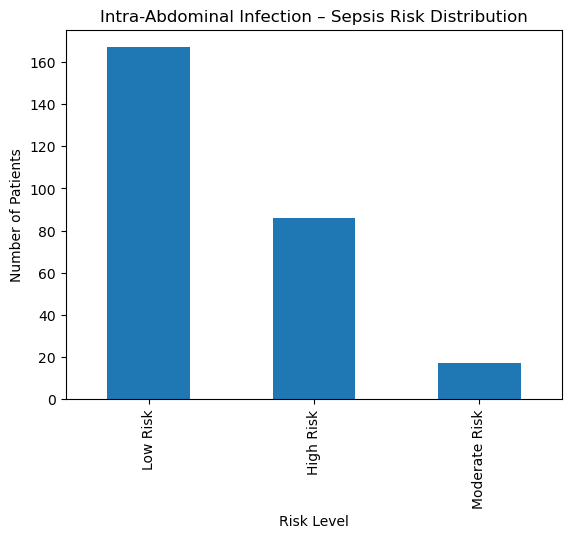

In [51]:
import matplotlib.pyplot as plt

results_abdominal["Sepsis_Risk_Level"].value_counts().plot(
    kind="bar",
    title="Intra-Abdominal Infection – Sepsis Risk Distribution"
)
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.show()


For intra-abdominal infection patients, the model predicts sepsis probability and classifies patients into no, low, moderate, and high risk categories to support early diagnosis in non-ICU settings

In [52]:
# Evaluate Model Performance

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Abdominal Infection RF Accuracy:", accuracy)


Abdominal Infection RF Accuracy: 0.9888888888888889


In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred, average="weighted"))

Precision: 0.9890083048363458
Recall: 0.9888888888888889
F1-score: 0.9888882067653016


In [54]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

        High       0.98      1.00      0.99        90
         Low       1.00      0.99      0.99        90
      Medium       0.99      0.98      0.98        90

    accuracy                           0.99       270
   macro avg       0.99      0.99      0.99       270
weighted avg       0.99      0.99      0.99       270



In [55]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

auc = roc_auc_score(
    y_test_bin,
    y_proba,
    multi_class='ovr'
)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9985185185185186


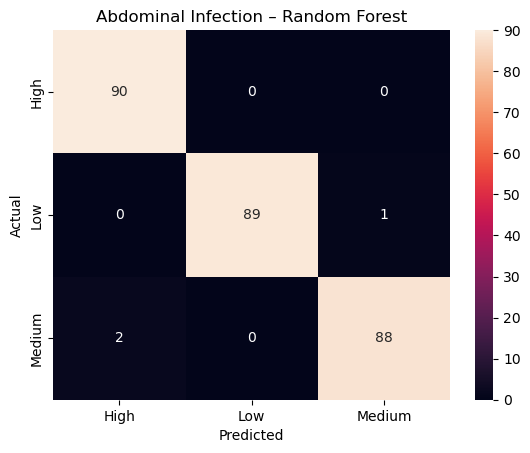

In [56]:
# Confusion Matrix (Visual) 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Abdominal Infection – Random Forest")
plt.show()


In [57]:
# Feature Importance
import numpy as np

importances = rf_abdominal.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)


,Feature,Importance
9,body_temperature,0.189853
21,platelets,0.132687
13,crp,0.124420
20,systolic_bp,0.109738
18,heart_rate,0.106116
19,respiratory_rate,0.089523
15,peritonitis,0.083629
10,wbc_count,0.033164
11,neutrophil_percentage,0.030849
0,age,0.030469


In [58]:
# Save Model & Scaler
import joblib

joblib.dump(rf_abdominal, "abdominal_random_forest_model.pkl")
joblib.dump(scaler, "abdominal_scaler.pkl")
joblib.dump(list(X.columns), "models/abdominal_features.pkl")
joblib.dump(le, "abdominal_label_encoder.pkl")

['abdominal_label_encoder.pkl']

For intra-abdominal infections, we trained a Random Forest classifier using early non-ICU clinical features. The model achieved good accuracy and high recall for high-risk sepsis cases, making it suitable for early risk prediction.

In [59]:
results_abdominal.to_csv("results_abdominal.csv", index=False)


We trained a Random Forest classifier for abdominal infection–related sepsis because it can model non-linear interactions between clinical symptoms and lab values. Class imbalance was handled using balanced class weights, and probability-based risk stratification was used to classify sepsis severity.”

In [60]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_abdominal,
    X_scaled,
    y_resampled,
    cv=10
)

print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.9680265339966831
